# Measuring the angular two-point correlation function of DMASS

In the previous notebook you built your own DMASS sample by training the Extreme
Deconvolution model and assigning each galaxy a CMASS membership probability. Now
we ask the central validation question: **does your DMASS sample cluster on the sky
the same way the real CMASS sample does?**

The angular two-point correlation function, $w(\theta)$, measures exactly this: how much more likely you are to find two galaxies separated
by an angle $\theta$ than you would be if the galaxies were placed at random. If DMASS truly mimics CMASS, the two samples live in the same dark-matter environments and should share the same $w(\theta)$. 

In this notebook you will (1) measure $w(\theta)$ for your DMASS sample, (2) overlay it on the
CMASS measurement, and (3) put a *number* on how well they agree using a $\Delta \chi^2$ and a `p-value`.

In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import fitsio
import treecorr

# Make plots look nicer
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13


%matplotlib inline
%load_ext autoreload
%autoreload 2

# Load your DMASS and Random Catalogues

To measure clustering we need two catalogues:

- **the DMASS sample** — your sample, the one whose clustering we want to measure;
- **a random catalogue** — points scattered *uniformly* across the exact same patch of
  sky, with no clustering at all.

In [2]:
your_dmass_filename = '../output/cat/test_ra330_360.fits'
dmass = fitsio.read(your_dmass_filename)


random_filename = '/fs/ess/PHS0411/summer/randoms_ra300_360_dec_-3_3.fits'
random = fitsio.read(random_filename)
spatial_cut =  (random['RA'] > 330) & (random['RA'] < 360)
random = random[spatial_cut]

The randoms start as points uniformly filling a simple rectangle (300 < RA < 360, −3 < Dec < 3). But the real DES data does not fill a clean rectangle. It has an irregular
footprint, and some regions are removed because of bright-star contamination, satellite trails, or bad imaging.

The crucial rule: **whatever mask we apply to the galaxies, we must apply the identical mask to the randoms.** The randoms have to occupy *exactly* the same sky as the galaxies, otherwise the estimator will mistake the footprint shape for real clustering. Below we apply the same `redsample` mask to both.

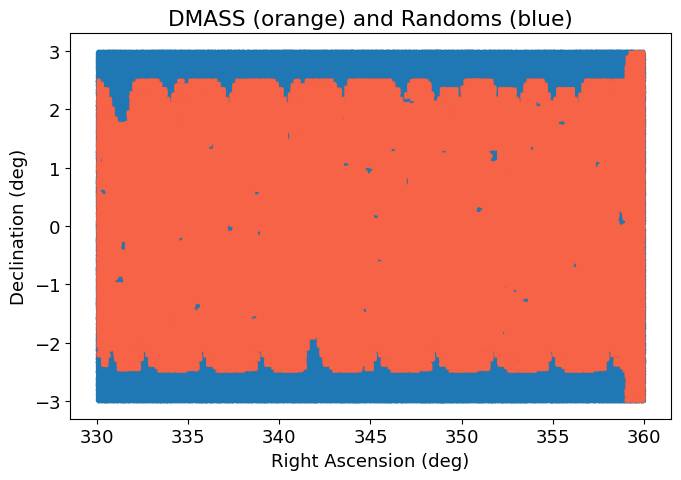

In [3]:
fig, ax = plt.subplots(1,1, figsize=(7, 5))

ax.scatter(random['RA'], random['DEC'], s=2, alpha=0.5, color='tab:blue', rasterized=True)
ax.scatter(dmass['RA'], dmass['DEC'], s=1, alpha=0.1, color='tomato', rasterized=True)


ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('DMASS (orange) and Randoms (blue)')


plt.tight_layout()
plt.show()

Here, you apply masks!

In [4]:
def apply_redsample_mask( sample ):
    mask_filename= '/fs/ess/PHS0411/summer/MASK_Y3LSSREDSOF_M22DERED_v2_2_1.fits'
    mask = fitsio.read(mask_filename)
    sample_mask = np.in1d( sample['HPIX_4096'], mask['pixel'] )
    return sample[sample_mask]

# ----------------------------------------

random = apply_redsample_mask(random)
dmass = apply_redsample_mask(dmass)

/tmp/ipykernel_498550/2319366622.py:4: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  sample_mask = np.in1d( sample['HPIX_4096'], mask['pixel'] )


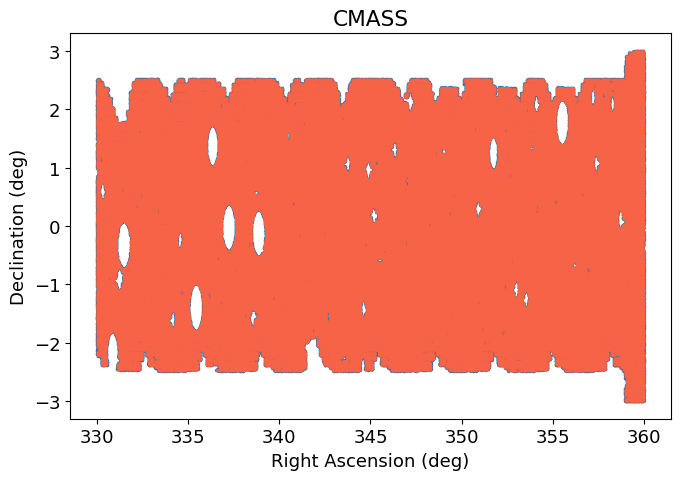

In [5]:
fig, ax = plt.subplots(1,1, figsize=(7, 5))

ax.scatter(random['RA'], random['DEC'], s=2, alpha=0.5, color='tab:blue', rasterized=True)
ax.scatter(dmass['RA'], dmass['DEC'], s=1, alpha=0.1, color='tomato', rasterized=True)


ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('CMASS')

plt.tight_layout()
plt.show()

Now galaxy catalogues and Randoms cover the same sky! 

# Compute corelation function

Now, you repeat what you did in `correlation_function.ipynb` notebook, but this time you use with your DMASS sample and the corresponding randoms. 
We use CMASS_probability as weight! 

Unlike CMASS, DMASS is not a simple yes/no sample. The Extreme Deconvolution model gives each galaxy a *probability* of being CMASS-like, stored in `CMASS_PROB`. Instead of drawing a hard threshold and discarding everything below it, we keep all galaxies and weight each one by its probability: a galaxy that is almost certainly
CMASS-like (prob ~ 1) counts fully, while one that probably isn't (prob ~ 0.05) contributes very little. This uses all the information the model provides, and is exactly how DMASS is meant to be used. The randoms carry no weight — they only trace the geometry.

In [6]:
# use CMASS probability as weight 
weight_dmass = dmass['CMASS_PROB']
weight_random = None

In [ ]:
data = treecorr.Catalog(ra=dmass['RA'], dec=dmass['DEC'], 
                        w = weight_dmass, ra_units='deg', dec_units='deg', npatch=30)
rand = treecorr.Catalog(ra=random['RA'], dec=random['DEC'], 
                        is_rand=True, w = weight_random, ra_units='deg', dec_units='deg', patch_centers=data.patch_centers)

### Don't forget to save your results at the end! 

In [ ]:

nbins = 10 # number of bins in angular separation
# range of angular separations, in arcmin ( 60 arcmin = 1 degree ). 
sep_units = 'arcmin'
min_sep = 2.5 # minimum angular separation in arcmin (leftmost point on x-axis). 
max_sep = 250 # maximum angular separation in arcmin (rightmost point on x-axis)
var_method='jackknife'
verbose=2

# DD pair counts, DR pair counts, and RR pair counts in the Landy-Szalay estimator
DD = treecorr.NNCorrelation(nbins = nbins, max_sep = max_sep, min_sep= min_sep, sep_units=sep_units, var_method=var_method, verbose=verbose)
DR = treecorr.NNCorrelation(nbins = nbins, max_sep = max_sep, min_sep= min_sep, sep_units=sep_units, verbose=verbose)
RR = treecorr.NNCorrelation(nbins = nbins, max_sep = max_sep, min_sep= min_sep, sep_units=sep_units, verbose=verbose)

DD.process(data)
DR.process(data, rand)
RR.process(rand)

# angular separation theta is stored in DD.meanr
theta = DD.meanr
# angular correlation function w(theta) is calculated using the Landy-Szalay estimator
wtheta, err_wtheta = DD.calculateXi(rr=RR,dr=DR)


# save your result -------------------------------------------------------------
your_file_name='../output/correlation_function/wtheta_dmass_jk30_ra330_360.txt'
DD.write(your_file_name)
# save covariance matrix 
np.savetxt('../output/correlation_function/cov_dmass_jk30_ra330_360.npy', DD.cov)

# 

nbins = 10, min,max sep = 2.5..250 arcmin, bin_size = 0.460517
nbins = 10, min,max sep = 2.5..250 arcmin, bin_size = 0.460517
nbins = 10, min,max sep = 2.5..250 arcmin, bin_size = 0.460517
Process patch 0 auto
Starting process NN auto-correlations for cat patch 0.
Using 40 threads.
Starting 64 jobs.
................................................................
Process patches 0, 29 cross
Skipping (0, 29) pair, which are too far apart for this set of separations
Process patches 0, 28 cross
Skipping (0, 28) pair, which are too far apart for this set of separations
Process patches 0, 27 cross
Skipping (0, 27) pair, which are too far apart for this set of separations
Process patches 0, 26 cross
Skipping (0, 26) pair, which are too far apart for this set of separations
Process patches 0, 25 cross
Skipping (0, 25) pair, which are too far apart for this set of separations
Process patches 0, 24 cross
Skipping (0, 24) pair, which are too far apart for this set of separations
Process patches 

# Plot and compare with CMASS

Let's overlay your DMASS measurement (red) on the CMASS measurement (black). We make two versions:

- **$w(\theta)$** — the raw correlation function. The signal is strongest at small
  separations and falls quickly, so on a log-x axis most of the action is squeezed left.
- **$\theta w(\theta)$** — multiplying by θ flattens the curve and spreads the points out, making
  differences between the two samples much easier to see by eye.

A note on the DMASS error bars: this DMASS footprint is small (a couple of narrow RA
strips), so a jackknife covariance estimated directly from it would be very noisy. As a
shortcut we borrow the well-measured CMASS covariance and rescale it by the ratio of survey
areas (CMASS area is $2525 \,{\rm deg}^2$, and the DES test region is roughly $150 \,{\rm deg}^2$) — a smaller area means larger sample variance, so the covariance scales roughly as 1/Area. That is what `cov_cmass * 2525/150` does.

In [3]:
# call cmass correlation function
result_cmass = np.genfromtxt('/fs/ess/PHS0411/summer/correlation_function/wtheta_cmass_jk100.txt', names=True, skip_header=1)
cov_cmass = np.genfromtxt('/fs/ess/PHS0411/summer/correlation_function/cov_cmass_jk100.txt')

theta_cmass = result_cmass['meanr']
wtheta_cmass = result_cmass['xi']
err_wtheta_cmass = result_cmass['sigma_xi']

In [4]:
# load your saved result
result_dmass = np.genfromtxt('../output/correlation_function/wtheta_dmass_jk30_ra330_360.txt', names=True, skip_header=1)

# DMASS footprint is small. We derive DMASS covariance matrix from the CMASS covariance matrix, by multiplying the ratio of Areas.  
cov_dmass = cov_cmass * 2525/150

theta = result_dmass['meanr']
wtheta = result_dmass['xi']
err_wtheta = np.sqrt(cov_dmass.diagonal())

Text(0.5, 1.0, 'angular correlation function of DMASS galaxies')

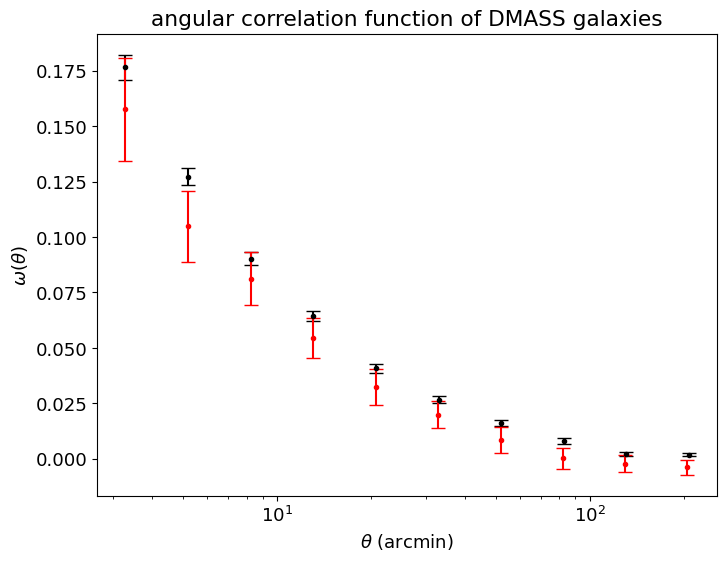

In [5]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

ax.errorbar(theta_cmass, wtheta_cmass, yerr=err_wtheta_cmass, fmt='.', capsize=5,  color='black')
ax.errorbar(theta, wtheta, yerr=err_wtheta, fmt='.', capsize=5,  color='red')

ax.set_xscale('log')  # Plot on log scale
ax.set_xlabel('$\\theta$ (arcmin)')
ax.set_ylabel('$\\omega(\\theta)$')
ax.set_title('angular correlation function of DMASS galaxies')


Text(0.5, 1.0, 'angular correlation function of DMASS galaxies')

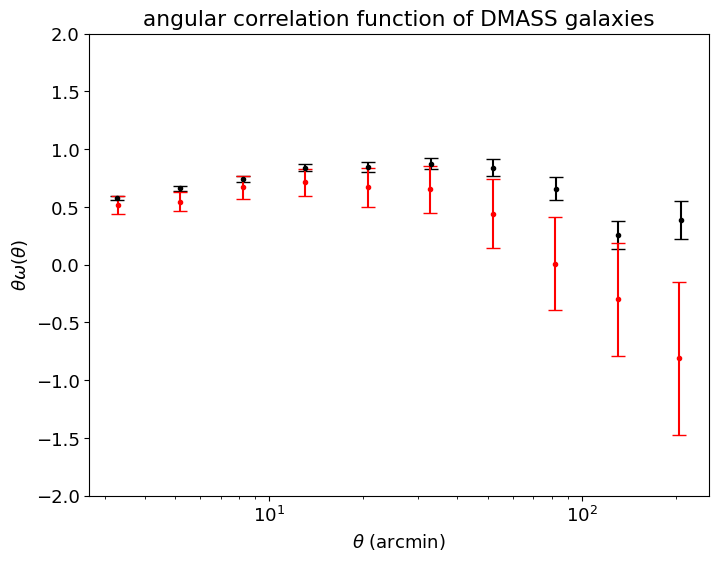

In [6]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

ax.errorbar(theta_cmass, theta_cmass*wtheta_cmass, yerr=theta_cmass*err_wtheta_cmass, fmt='.', capsize=5,  color='black')
ax.errorbar(theta, theta*wtheta, yerr=theta*err_wtheta, fmt='.', capsize=5,  color='red')

ax.set_ylim( -2, 2)
ax.set_xscale('log')  # Plot on log scale
ax.set_xlabel('$\\theta$ (arcmin)')
ax.set_ylabel('$\\theta \\omega(\\theta)$')
ax.set_title('angular correlation function of DMASS galaxies')


# How similar are they? Compute $\Delta\chi^2$ and a p-value.

You now have two measurements of $w(\theta)$: one for your DMASS sample, one for CMASS. On
the plot they *look* close. But "looks close" is not science. We want a single number that
says how well they agree, taking the error bars into account.

### The idea: add up the disagreements

At each angular bin $\theta_i$, look at the difference between the two curves,
$\Delta_i = w^{\rm DMASS}(\theta_i) - w^{\rm CMASS}(\theta_i)$, and measure it *in units of
its error bar*. Roughly speaking, $\chi^2$ adds up these disagreements across all bins:

$$ \chi^2 \;\approx\; \sum_i \left( \frac{\text{difference in bin } i}{\text{error in bin } i} \right)^2 . $$

A bin that's off by $1\sigma$ contributes about 1; a bin off by $3\sigma$ contributes about 9.
So $\chi^2$ is just a running total of "how many error bars apart are the two curves." If the
two samples really are the same, each bin is typically off by about $1\sigma$ from noise
alone, so $\chi^2$ should come out roughly equal to the number of bins, $d$ (the **degrees of
freedom**). That gives a handy benchmark: **$\chi^2/d \approx 1$ means good agreement.**

(The code does this a bit more carefully — neighbouring bins are correlated, so instead of
plain error bars it uses the full covariance matrix from the jackknife. The idea is the same;
you don't need to worry about the matrix algebra.)

### The p-value: is that $\chi^2$ big or small?

Say you get $\chi^2 = 12$. Is that a lot? On its own you can't tell. Even two *identical*
samples won't give exactly $\chi^2 = 0$, because random noise always creates some scatter. So
we ask the honest question:

> *If the two samples really were the same, how often would noise alone produce a $\chi^2$ at
> least this large?*

That probability is the **p-value**. It runs from 0 to 1:

- **Large p-value** (say $> 0.05$): a $\chi^2$ this size happens easily by chance, so the
  difference you see is consistent with just noise → the two samples **agree**. 
- **Small p-value** (say $< 0.01$): a $\chi^2$ this size would almost never happen by chance,
  so the difference is *real*, not noise → the two samples **genuinely differ**.

In short: **the p-value is roughly the probability that the difference you see is just noise.**
A small p-value means "probably not noise, Something is actually different about this sample."
And a real difference is interesting too: it tells you which selection choices pull your DMASS
sample away from CMASS.

---

After running the cell, print `delta_chi2`, `dof`, and `p_value`.

In [11]:

from scipy.stats import chi2 as chi2_dist

# difference between the two measurements 
difference = wtheta - wtheta_cmass

# degree of freedom (number of bins)
dof = len(difference)  

# Hartlap factor 
N = 100        # jackknife patch
hartlap = (N - dof - 2) / (N - 1)

# error matrix 
C = cov_cmass + cov_dmass
Cinv = hartlap * np.linalg.inv(C)
delta_chi2 = difference @ Cinv @ difference

p_value = chi2_dist.sf(delta_chi2, df=dof)


print(f'chi^2 = {delta_chi2:.2f} \ndof = {dof} \nchi^2 / dof = {delta_chi2/dof:.2f} \np = {p_value}')

chi^2 = 5.68 
dof = 10 
chi^2 / dof = 0.57 
p = 0.8413384373133503


Let's interprete those numbers! 

1. Compute $\chi^2/\mathrm{dof}$. Is it close to 1? How about p-value?
2. In one sentence: is your DMASS sample consistent with CMASS, and how confident are you?
3. You'll repeat this for each sample variant later. Which single number would you report to
   decide which variant is "most CMASS-like"?